# Pipeline Workflow And Tooling

        ## Manuscript targets
        - `Figure Workflow`
- `Table Tools`
- `Methodology / Data processing pipeline`

        ## Primary inputs
        - `share/scripts/pipeline/`

        ## Rebuild scripts
        - `share/scripts/pipeline/00_run_full_srr_pipeline.sh`

        This notebook prefers the full local `data/` working set when it exists and falls back to the tiny `share/data/` example bundle otherwise.


## Inputs, methodology, and rebuild policy

This notebook is intentionally structural rather than statistical. It documents the pipeline stages that feed the manuscript, maps them to the curated numbered script layout, and renders a compact workflow figure plus the tool/version table cited in the methods section.


In [1]:
from __future__ import annotations

import math
import re
import subprocess
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    # --- Standardized Plotting Configuration ---
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans", "sans-serif"],
        "font.size": 8,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })
    sns.set_theme(style="whitegrid", palette="colorblind")
    plt.rcParams.update({"font.family": "sans-serif"})
    # -------------------------------------------
except ImportError:
    sns = None

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)
SRR_PATTERN = re.compile(r"(SRR\d+)")


def find_repo_root() -> Path:
    start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "share").exists() and (candidate / "share" / "results").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the notebook working directory.")


REPO_ROOT = find_repo_root()
SHARE = REPO_ROOT / "share"
RESULTS = SHARE / "results"
TECH = RESULTS / "technical"
BIO = RESULTS / "biological"
SUPP = RESULTS / "supplementary"
SHARE_DATA = SHARE / "data"
LOCAL_DATA = REPO_ROOT / "data"
SCRIPTS = SHARE / "scripts"
NOTEBOOK_DB = SHARE / "notebooks" / "srr_queue.db"


def data_dir(name: str) -> Path:
    local = LOCAL_DATA / name
    if local.exists():
        return local
    return SHARE_DATA / name


def load_table(path: Path) -> pd.DataFrame:
    sep = "," if path.suffix == ".csv" else "\t"
    return pd.read_csv(path, sep=sep)


def run_script(script_rel: str, *args: str) -> None:
    script = REPO_ROOT / script_rel
    if not script.exists():
        raise FileNotFoundError(script)
    cmd = ["python3", str(script), *map(str, args)] if script.suffix == ".py" else ["bash", str(script), *map(str, args)]
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=REPO_ROOT)


def parse_fastqc_terminal_quality(fastqc_data_path: Path) -> float | None:
    rows: list[list[str]] = []
    in_section = False
    for line in fastqc_data_path.read_text(encoding="utf-8", errors="replace").splitlines():
        if line.startswith(">>Per base sequence quality"):
            in_section = True
            continue
        if in_section and line.startswith(">>END_MODULE"):
            break
        if in_section and line and not line.startswith("#"):
            rows.append(line.split("\t"))
    if not rows:
        return None
    means = []
    for row in rows:
        try:
            means.append(float(row[1]))
        except (IndexError, ValueError):
            continue
    if not means:
        return None
    return float(np.mean(means[-min(10, len(means)) :]))


def load_terminal_quality_table() -> pd.DataFrame:
    quality = load_table(TECH / "per_srr_quality.tsv")
    raw_dir = data_dir("flattened_fastqc_raw")
    rows = []
    if raw_dir.exists():
        for fastqc_data in raw_dir.glob("*/*_fastqc/fastqc_data.txt"):
            terminal_q = parse_fastqc_terminal_quality(fastqc_data)
            if terminal_q is None:
                continue
            project_id = fastqc_data.parents[1].name
            srr = fastqc_data.parent.name.removesuffix("_fastqc")
            if srr.endswith("_1") or srr.endswith("_2"):
                srr = srr[:-2]
            rows.append({
                "project_id": project_id,
                "SRR_ID": srr,
                "terminal_q_mean": terminal_q,
            })
    if rows:
        terminal = (
            pd.DataFrame(rows)
            .groupby(["project_id", "SRR_ID"], as_index=False)["terminal_q_mean"]
            .mean()
        )
        merged = quality.merge(terminal, on=["project_id", "SRR_ID"], how="left")
        merged["terminal_q_mean"] = merged["terminal_q_mean"].fillna(
            merged["Q_mean"] - merged["tail_quality_decay"]
        )
        return merged

    quality["terminal_q_mean"] = quality["Q_mean"] - quality["tail_quality_decay"]
    return quality


def srr_ids_from_tree(root: Path) -> set[str]:
    srrs: set[str] = set()
    if not root.exists():
        return srrs
    for path in root.rglob("*"):
        match = SRR_PATTERN.search(path.name) or SRR_PATTERN.search(path.as_posix())
        if match:
            srrs.add(match.group(1))
    return srrs


def flattened_dir_srr_sets(root: Path, cohort_projects: set[str] | None = None) -> dict[str, set[str]]:
    dir_sets: dict[str, set[str]] = {}
    if not root.exists():
        return dir_sets

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        dir_srrs: set[str] = set()
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            if cohort_projects is not None and project_dir.name not in cohort_projects:
                continue
            dir_srrs.update(srr_ids_from_tree(project_dir))
        dir_sets[flattened_dir.name] = dir_srrs
    return dir_sets


def collect_flattened_dir_audit(root: Path, cohort_projects: set[str] | None = None) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame(
            columns=[
                "flattened_dir",
                "projects_total",
                "unique_srrs_total",
                "projects_in_cohort",
                "unique_srrs_in_cohort",
                "projects_outside_cohort",
                "unique_srrs_outside_cohort",
                "outside_cohort_projects",
            ]
        )

    for flattened_dir in sorted(
        p for p in root.iterdir() if p.is_dir() and p.name.startswith("flattened_")
    ):
        project_srrs: dict[str, set[str]] = {}
        for project_dir in sorted(p for p in flattened_dir.iterdir() if p.is_dir()):
            project_srrs[project_dir.name] = srr_ids_from_tree(project_dir)

        all_srrs = set().union(*project_srrs.values()) if project_srrs else set()
        if cohort_projects is None:
            in_cohort = project_srrs
            out_cohort: dict[str, set[str]] = {}
        else:
            in_cohort = {k: v for k, v in project_srrs.items() if k in cohort_projects}
            out_cohort = {k: v for k, v in project_srrs.items() if k not in cohort_projects}

        in_srrs = set().union(*in_cohort.values()) if in_cohort else set()
        out_srrs = set().union(*out_cohort.values()) if out_cohort else set()

        rows.append(
            {
                "flattened_dir": flattened_dir.name,
                "projects_total": len(project_srrs),
                "unique_srrs_total": len(all_srrs),
                "projects_in_cohort": len(in_cohort),
                "unique_srrs_in_cohort": len(in_srrs),
                "projects_outside_cohort": len(out_cohort),
                "unique_srrs_outside_cohort": len(out_srrs),
                "outside_cohort_projects": ", ".join(sorted(out_cohort)) if out_cohort else "",
            }
        )

    return pd.DataFrame(rows)


In [2]:
pipeline_dir = SCRIPTS / "pipeline"
pipeline_scripts = sorted(pipeline_dir.glob("*"))
pipeline_inventory = pd.DataFrame(
    {
        "script": [p.name for p in pipeline_scripts if p.is_file()],
        "stage_prefix": [p.name.split("_", 1)[0] for p in pipeline_scripts if p.is_file()],
    }
)
pipeline_inventory.head(20)


,script,stage_prefix
0,00_run_full_srr_pipeline.sh,00
1,01_detect_fastq_layout_and_phred.sh,01
2,02_trim_reads_with_trimmomatic.sh,02
3,03_align_reads_with_bowtie2.sh,03
4,04_count_reads_with_featurecounts.sh,04
5,10_fetch_srr_fastqs.sh,10
6,11_fetch_srr_from_ncbi.sh,11
7,12_fetch_srr_from_ncbi_cloud.sh,12
8,13_fetch_srr_from_aws.sh,13
9,14_fetch_srr_from_gcp.sh,14


In [3]:
tool_table = pd.DataFrame(
    [
        ("SRA Toolkit", "3.4.1", "SRR retrieval and FASTQ conversion"),
        ("FastQC", "0.12.1", "Raw-read quality summaries"),
        ("Trimmomatic", "0.40", "Adapter and quality trimming"),
        ("Bowtie2", "2.5.4", "Read alignment"),
        ("Samtools", "1.23 / htslib 1.23", "BAM conversion and sorting"),
        ("featureCounts / Subread", "2.1.1", "Gene-level counting"),
        ("Java/OpenJDK", "11.0.25", "Trimmomatic runtime"),
        ("Python", "3.14.3", "Glue code and analysis scripts"),
        ("clusterProfiler", "Bioconductor", "ORA and GSEA pathway analysis"),
        ("org.Hs.eg.db", "Bioconductor", "Gene annotation"),
    ],
    columns=["Tool", "Version", "Role"],
)
display(tool_table)


,Tool,Version,Role
0,SRA Toolkit,3.4.1,SRR retrieval and FASTQ conversion
1,FastQC,0.12.1,Raw-read quality summaries
2,Trimmomatic,0.40,Adapter and quality trimming
3,Bowtie2,2.5.4,Read alignment
4,Samtools,1.23 / htslib 1.23,BAM conversion and sorting
5,featureCounts / Subread,2.1.1,Gene-level counting
6,Java/OpenJDK,11.0.25,Trimmomatic runtime
7,Python,3.14.3,Glue code and analysis scripts
8,clusterProfiler,Bioconductor,ORA and GSEA pathway analysis
9,org.Hs.eg.db,Bioconductor,Gene annotation


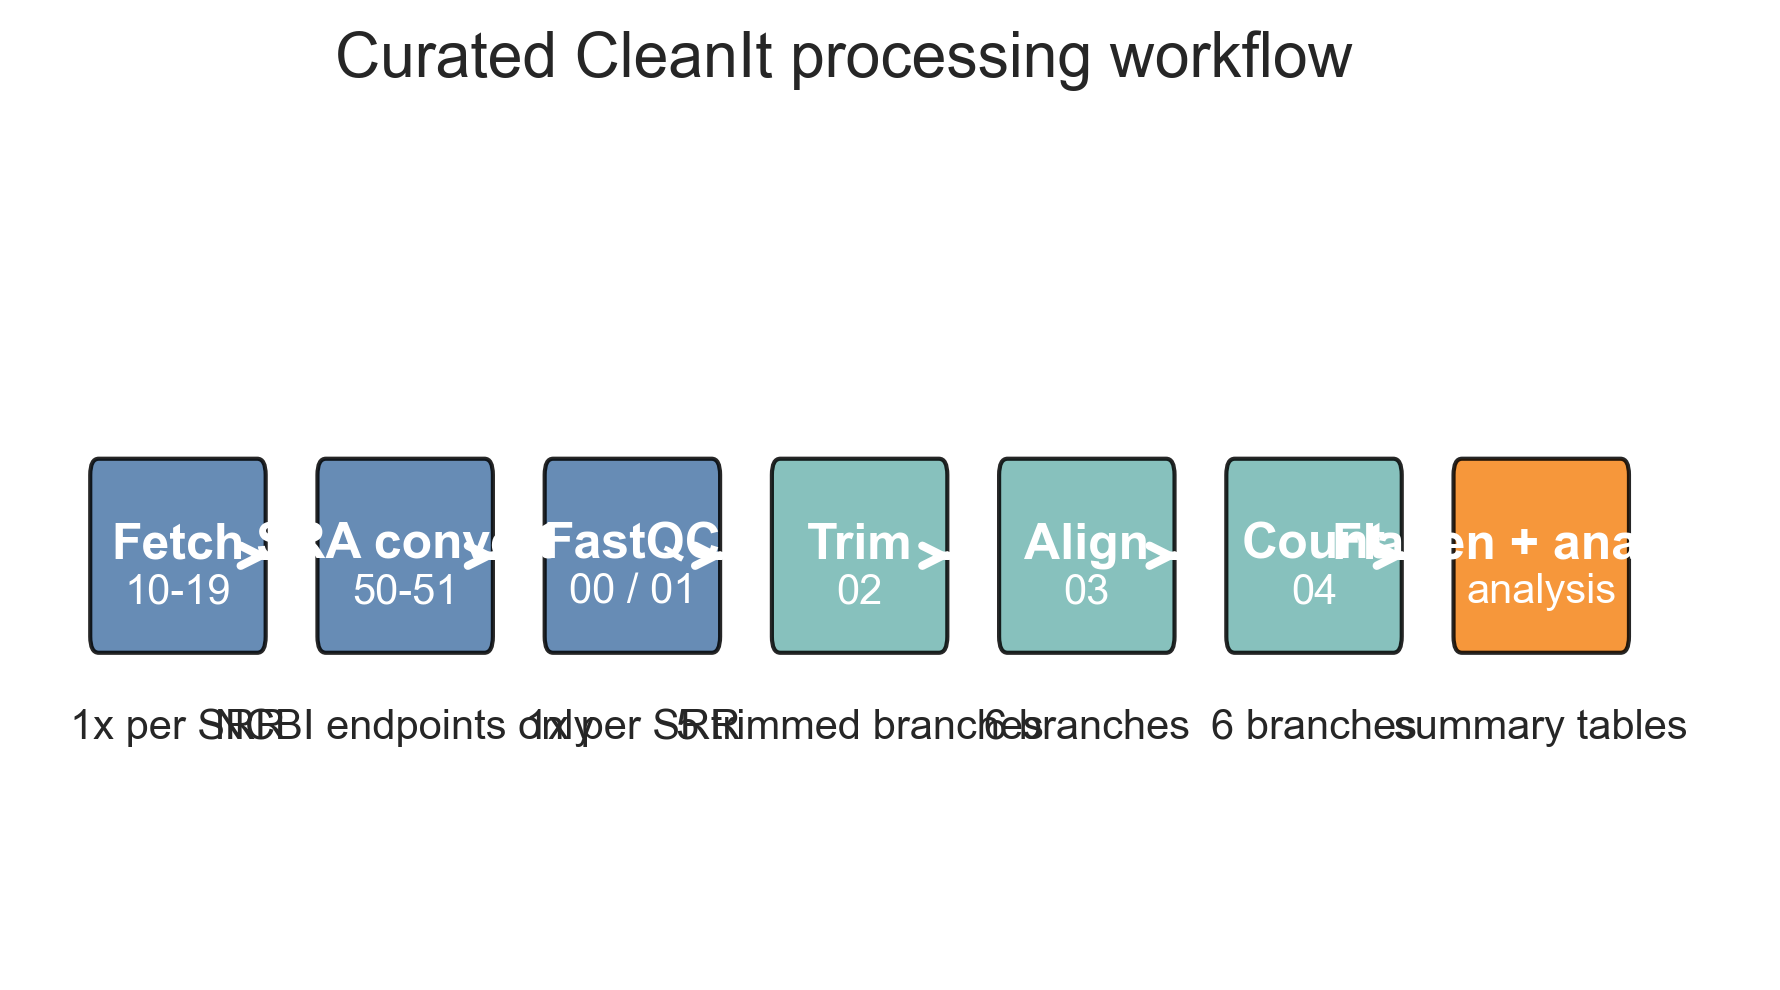

In [4]:
from matplotlib.patches import FancyBboxPatch

stages = [
    ("Fetch", "10-19", "1x per SRR"),
    ("SRA convert", "50-51", "NCBI endpoints only"),
    ("FastQC", "00 / 01", "1x per SRR"),
    ("Trim", "02", "5 trimmed branches"),
    ("Align", "03", "6 branches"),
    ("Count", "04", "6 branches"),
    ("Flatten + analysis", "analysis", "summary tables"),
]

fig, ax = plt.subplots(figsize=(7.0, 3.5))
ax.set_xlim(0, len(stages) * 2.2)
ax.set_ylim(0, 4)
ax.axis("off")

for idx, (label, prefix, note) in enumerate(stages):
    x = 0.6 + idx * 2.15
    y = 2
    patch = FancyBboxPatch(
        (x, y - 0.45),
        1.6,
        0.9,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        facecolor="#4C78A8" if idx < 3 else "#72B7B2" if idx < 6 else "#F58518",
        edgecolor="black",
        alpha=0.85,
    )
    ax.add_patch(patch)
    ax.text(x + 0.8, y + 0.05, label, ha="center", va="center", color="white", fontsize=12, weight="bold")
    ax.text(x + 0.8, y - 0.18, prefix, ha="center", va="center", color="white", fontsize=10)
    ax.text(x + 0.8, y - 0.85, note, ha="center", va="center", fontsize=10)
    if idx < len(stages) - 1:
        ax.annotate("", xy=(x + 1.75, y), xytext=(x + 1.55, y), arrowprops=dict(arrowstyle="->", lw=2))

ax.set_title("Curated CleanIt processing workflow", fontsize=15, pad=18)
plt.show()

from pathlib import Path
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/pipeline_workflow_and_tooling_fig1.png", bbox_inches="tight")
fig.savefig("figures/pipeline_workflow_and_tooling_fig1.pdf", bbox_inches="tight")
fig.savefig("figures/pipeline_workflow_and_tooling_fig1.svg", bbox_inches="tight")